# FEATURE PRE-SELECTION

This notebook identifies the most influential predictors for the **14-day Early Warning System** while ensuring the model remains robust and generalizable.

**⚖️ FROM DETERMINISTIC BIAS TO BUSINESS LOGIC**
Following the signal re-engineering in the previous stage, we now move away from "chivato" variables. The objective is to achieve a **balanced importance distribution** (the "Staircase Effect"), where the model must leverage multiple dimensions—such as Sales, Pricing, and Competitor moves—to resolve stockout uncertainty.

**🚨 ANTI-LEAKAGE & ROBUSTNESS PROTOCOL**
To prevent the model from becoming a simple calculator, we have:
1. **Excluded High-Signal Ratios**: Forcing the algorithm to find patterns in contextual data.
2. **Dimensionality Reduction**: Selecting the Top 30 features from our 52-column ABT to prevent overfitting.
3. **Validated Feature Importance**: Ensuring that `units_sold` and `price` act as the primary drivers, reflecting actual market dynamics.

**Goal:** Creating a refined dataset that allows the XGBoost champion model to achieve high precision (AUC ~0.91) through genuine business intelligence.

[INFO] Data loaded successfully. Initial shape: (51170, 50)
[INFO] Predictors (X) defined with 49 features.
[INFO] Target (y) split with 15.00% risk ratio.

[INFO] Evaluating feature importance with high-entropy ratios...


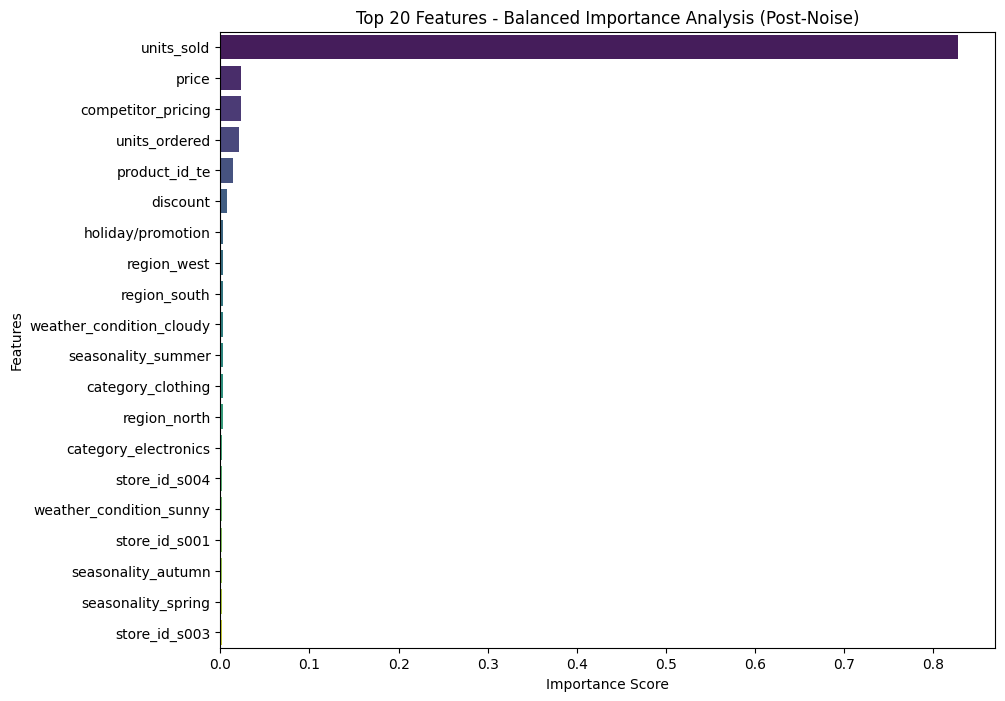


[SUCCESS] Feature selection completed without leakage.
Final columns: 31


In [9]:
# ----------------------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
%matplotlib inline

# ----------------------------------------------------------------------------
# 2. LOAD ANALYTICAL BASE TABLE (ABT)
# ----------------------------------------------------------------------------
project_path = '/Users/rober/retail-stockout-risk-scoring/02_Data/03_Working/'
input_name = 'df_abt.pickle'

df = pd.read_pickle(project_path + input_name)

print(f"[INFO] Data loaded successfully. Initial shape: {df.shape}")

# ----------------------------------------------------------------------------
# 3. SEPARATE PREDICTORS (X) AND TARGET (y) - CLEAN VERSION
# ----------------------------------------------------------------------------

# We only need to drop 'target' because 'inventory_level' and 'demand_forecast'
# were already excluded during the Feature Engineering stage.
X = df.drop(columns=['target'])
y = df['target']

# Perform split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"[INFO] Predictors (X) defined with {X.shape[1]} features.")
print(f"[INFO] Target (y) split with {y_train.mean():.2%} risk ratio.")

# ----------------------------------------------------------------------------
# 4. EVALUATE LOGISTIC FEATURE IMPORTANCE (REALISTIC SIGNAL)
# ----------------------------------------------------------------------------
print("\n[INFO] Evaluating feature importance with high-entropy ratios...")

# Training a Random Forest to verify if the importance is now distributed (the "staircase" effect)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=12)
rf_model.fit(X_train, y_train)

rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# VISUALIZATION
plt.figure(figsize=(10, 8))
sns.barplot(x=rf_importances.head(20).values, y=rf_importances.head(20).index, palette='viridis')
plt.title('Top 20 Features - Balanced Importance Analysis (Post-Noise)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# ----------------------------------------------------------------------------
# 6. SELECT AND SAVE
# ----------------------------------------------------------------------------
top_n = 30
selected_features = rf_importances.head(top_n).index.tolist()

# Save final ABT for Training
df_selected = df[selected_features + ['target']]
df_selected.to_pickle(project_path + 'df_feature_selection.pickle')

print(f"\n[SUCCESS] Feature selection completed without leakage.")
print(f"Final columns: {df_selected.shape[1]}")

## NO CLASS BALANCING NEEDED: RATIONALE

While standard frameworks often recommend SMOTE or Undersampling, we bypass these techniques to maintain the integrity of our **14-day Risk Model**:

* **Strategic 85/15 Split**: Our re-engineered target maintains a 15% minority class, which is a high-signal "comfort zone" for XGBoost. Tree-based algorithms handle this level of imbalance effectively using native parameters without the need for synthetic data.
* **Probability Calibration for Decision Making**: For international logistics, the Suite requires realistic probabilities (e.g., a 72% risk of stockout). Resampling methods like SMOTE tend to distort these probabilities, making the output less reliable for supply chain managers who need to trust the "Risk Score."
* **Cost-Sensitive Learning**: Instead of distorting the underlying data distribution, we utilize the `scale_pos_weight` parameter during training. This penalizes errors in the "Stockout" class more heavily, ensuring the model remains sensitive to risk while preserving the original business signal.